In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Setup for Stackelberg
# Altitude bound for attacker
h_min = 1.0
h_max = 3.0

# Detection Mmodel parameter
alpha = 1
k = 2

In [3]:
def distance(a, b):
    return np.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

In [4]:
def ang_to_alt(theta):
    """Convert from LOS angle of sensor to altitude"""
    # return horitz_dist*np.tan(theta)
    return k*theta

In [5]:
def attacker_strategy(theta):
    """
    Given defender's LOS angle theta, return attacker's best altitude

    input: theta (LOS angle)
    output: h* (a* given d*)
    """

    # Sensor focus altitude
    focus_alt = ang_to_alt(theta)

    # If sensor is aimed too low, attacker goes as high as possible
    if focus_alt < h_min:
        return h_max
    # If sensor is aimed too high, attacker goes as low as possible
    elif focus_alt > h_max:
        return h_min
    # If sensor is aimed between altitude range: d \in [h_min, h_max]
    # Select altitude h* s.t. maximize cost function: |h - ang_to_alt(theta)| --> furthest vertical distance from sensor focus
    else:
        dist_low = abs(focus_alt - h_min)
        dist_high = abs(focus_alt - h_max)
        if dist_low >= dist_high:
            return h_min
        else:
            return h_max

In [6]:
def prob_of_detection(h, theta):
    """
    Probability of Detection model with exponential decay and range
    """

    focus_alt = ang_to_alt(theta)
    # Evalute the exponential with the squared difference btw h and focus_alt
    # return np.exp(-alpha*(distance([0, 0], [5, focus_alt]))**2)
    return np.exp(-alpha*(h - focus_alt)**2)

In [7]:
# Defender strategy setup
min_theta = 0
max_theta = 2
def_strat = np.linspace(min_theta, max_theta, 101)

# At each defender strategy def_strat, obtain best attacker strategy
h_star_vec = np.zeros_like(def_strat)
PoD_vec = np.zeros_like(def_strat)

for i, theta in enumerate(def_strat):
    # Follower: Select a* given d
    h_star = attacker_strategy(theta)
    h_star_vec[i] = h_star

    # Leader: Select d* given a* at previous d
    PoD_vec[i] = prob_of_detection(h_star, theta)

In [8]:
# Find defender's optimal beam angle
max_index = np.argmax(PoD_vec)
theta_star = def_strat[max_index]
h_star_given_d_star = h_star_vec[max_index]
d_star = PoD_vec[max_index]

print('a*: '+str(h_star_given_d_star))
print('d*: '+str(np.rad2deg(theta_star)))

a*: 1.0
d*: 57.29577951308232


Text(0.5, 1.0, 'Resulted PoD')

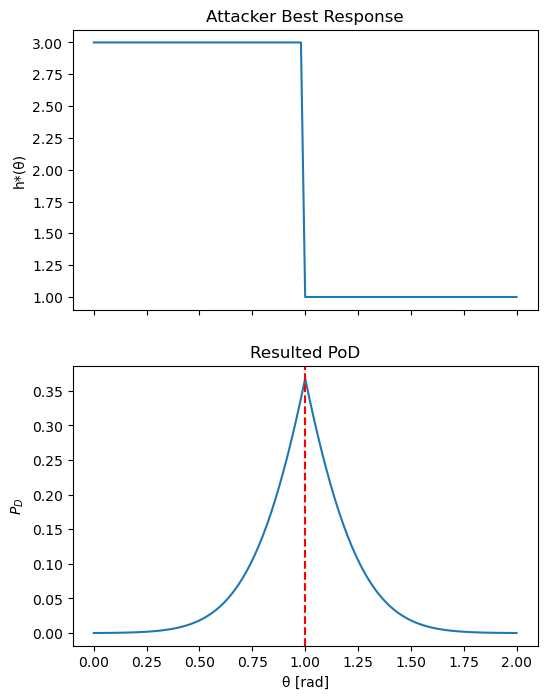

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6,8), sharex = True)
# Attacker Best Response
axs[0].plot(def_strat, h_star_vec)
axs[0].set_ylabel('h*(θ)')
# axs[0].grid(True)
axs[0].set_title('Attacker Best Response')

# Defender Probability
axs[1].plot(def_strat, PoD_vec)
axs[1].axvline(theta_star, linestyle='--', color='r')
axs[1].set_xlabel('θ [rad]')
axs[1].set_ylabel('$P_D$')
axs[1].set_title('Resulted PoD')
# axs[1].grid(True)


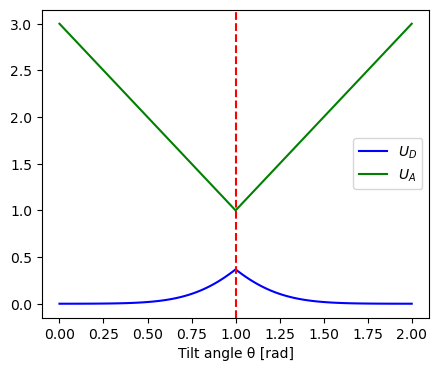

In [10]:
# Utility Comparison for Attacker / Defender
util_defender = PoD_vec
util_attacker = np.abs(h_star_vec - ang_to_alt(def_strat))

plt.figure(figsize=(5,4))
plt.plot(def_strat, util_defender, label='$U_D$', color='b')
plt.plot(def_strat, util_attacker, label='$U_A$', color='g')
plt.axvline(theta_star, linestyle='--', color='r')
plt.xlabel('Tilt angle θ [rad]')
plt.legend()

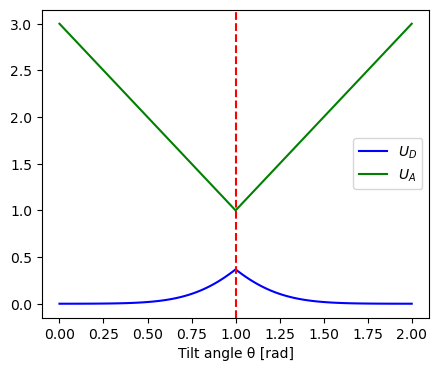

In [11]:
# Utility Comparison for Attacker / Defender
util_defender = PoD_vec
util_attacker = np.abs(h_star_vec - ang_to_alt(def_strat))

plt.figure(figsize=(5,4))
plt.plot(def_strat, util_defender, label='$U_D$', color='b')
plt.plot(def_strat, util_attacker, label='$U_A$', color='g')
plt.axvline(theta_star, linestyle='--', color='r')
plt.xlabel('Tilt angle θ [rad]')
plt.legend()